In [29]:
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, classification_report
from matplotlib import pyplot as plt

In [2]:
%run "../04_dataset_transforms/dataset.ipynb"

Train: 3094
Validation: 774
{'ambulance': 0, 'autobus': 1, 'kamyun': 2, 'minibus': 3, 'savari': 4, 'taxi': 5, 'vanet': 6}
Train dataset size: 3094
Validation dataset size: 774
Image type: <class 'PIL.Image.Image'>
Label: 0
Image size: (207, 276)
Label type: <class 'int'>
Original size: (207, 276)
Resized size: (224, 224)
Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Min: tensor(0.0118)
Max: tensor(1.)
Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0
Label type: <class 'int'>


In [ ]:
# %run "../05_dataloader/dataloader.ipynb"

In [4]:
train_transform_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 10.1 — new dataset

In [5]:
train_dataset_aug = TrafficVehicleDataset(
    train_df,
    class_to_idx,
    transform=train_transform_aug
)
val_dataset_aug = TrafficVehicleDataset(
    val_df,
    class_to_idx,
    transform=val_transform
)

# 10.2 — new dataLoader

In [7]:
batch_size = 32
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True
)
val_loader_aug = DataLoader(
    val_dataset_aug,
    batch_size=batch_size,
    shuffle=False
)

In [12]:
images , labels = next(iter(train_loader_aug))
print('images shape:',images.shape)
print('labels shape:',labels.shape)

images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])


# 10.3 — Baseline CNN

In [14]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 10.4 — model, loss, optimizer, decive

In [20]:
model_aug = BaselineCNN(num_classes=7)
print(model_aug)
print('='*80)

criterion_aug = nn.CrossEntropyLoss()
print("Loss:", criterion_aug)
print('='*80)

optimizer_aug = torch.optim.Adam(
    model_aug.parameters(),
    lr=0.001
)
print("Optimizer:\n", optimizer_aug)
print('='*80)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print('Device:',device)
model_aug = model_aug.to(device)
print("Model device:", next(model_aug.parameters()).device) 

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=7, bias=True)
  )
)
Loss: CrossEntropyLoss()
Optimizer:
 Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Device: cpu
Model device: cpu


# 10.5 — Training loop 

In [ ]:
num_epochs = 10
train_losses_aug = []
val_losses_aug = []
val_accuracies_aug = []

best_val_accuracy_aug = 0.0
best_epoch_aug = 0

for epoch in range(num_epochs):

    # Training
    model_aug.train()
    train_running_loss = 0.0
    for images, labels in train_loader_aug:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_aug.zero_grad()
        outputs = model_aug(images)

        loss = criterion_aug(outputs, labels)
        loss.backward()

        optimizer_aug.step()
        train_running_loss += loss.item()

    train_loss = train_running_loss / len(train_loader_aug)


    # Validation
    model_aug.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader_aug:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model_aug(images)
            loss = criterion_aug(outputs, labels)

            val_running_loss += loss.item()
            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    val_loss = val_running_loss / len(val_loader_aug)
    val_accuracy = correct / total

    # save results
    train_losses_aug.append(train_loss)
    val_losses_aug.append(val_loss)
    val_accuracies_aug.append(val_accuracy)


    # save best model
    if val_accuracy > best_val_accuracy_aug:

        best_val_accuracy_aug = val_accuracy
        best_epoch_aug = epoch + 1

        torch.save(
            model_aug.state_dict(),
            "best_augmentation_cnn.pth"
        )
        print("  --> Best augmentation model saved!")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

print()
print("Best Epoch:", best_epoch_aug)
print("Best Validation Accuracy:", best_val_accuracy_aug)

  --> Best augmentation model saved!
Epoch [1/10] Train Loss: 2.1063 Val Loss: 1.1965 Val Accuracy: 0.5943
  --> Best augmentation model saved!
Epoch [2/10] Train Loss: 1.0593 Val Loss: 0.8763 Val Accuracy: 0.7145
  --> Best augmentation model saved!
Epoch [3/10] Train Loss: 0.7863 Val Loss: 0.7560 Val Accuracy: 0.7364
  --> Best augmentation model saved!
Epoch [4/10] Train Loss: 0.6538 Val Loss: 0.6928 Val Accuracy: 0.7791
Epoch [5/10] Train Loss: 0.5763 Val Loss: 0.7063 Val Accuracy: 0.7713
Epoch [6/10] Train Loss: 0.5111 Val Loss: 0.7359 Val Accuracy: 0.7636
  --> Best augmentation model saved!
Epoch [7/10] Train Loss: 0.4381 Val Loss: 0.6953 Val Accuracy: 0.7868
  --> Best augmentation model saved!
Epoch [8/10] Train Loss: 0.3935 Val Loss: 0.6457 Val Accuracy: 0.7972
Epoch [9/10] Train Loss: 0.3755 Val Loss: 0.7738 Val Accuracy: 0.7804
Epoch [10/10] Train Loss: 0.3857 Val Loss: 0.6472 Val Accuracy: 0.7933

Best Epoch: 8
Best Validation Accuracy: 0.7971576227390181


# 10.6 — ارزیابی Baseline روی Validation

In [23]:
best_model_path = "best_augmentation_cnn.pth"
model_aug.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)
model_aug = model_aug.to(device)
model_aug.eval()
print("Best augmentation model loaded successfully.")

Best augmentation model loaded successfully.


In [24]:
all_predictions_aug = []
all_labels_aug = []
model_aug.eval()
with torch.no_grad():
    for images, labels in val_loader_aug:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_aug(images)
        predictions = outputs.argmax(dim=1)

        all_predictions_aug.extend(predictions.cpu().numpy())
        all_labels_aug.extend(labels.cpu().numpy())
        
print("Number of predictions:", len(all_predictions_aug))
print("Number of labels:", len(all_labels_aug))

Number of predictions: 774
Number of labels: 774


# 10.7 — Precision , Recall , F1 , confusion_matrix

In [26]:
accuracy = accuracy_score(all_labels_aug, all_predictions_aug)
precision = precision_score(all_labels_aug, all_predictions_aug, average="macro")
recall = recall_score(all_labels_aug, all_predictions_aug, average="macro")
f1 = f1_score(all_labels_aug, all_predictions_aug, average="macro")
cm = confusion_matrix(all_labels_aug, all_predictions_aug)

print("Augmentation Results")
print('=' * 40)
print("Validation Accuracy :", accuracy)
print("Validation Precision:", precision)
print("Validation Recall   :", recall)
print("Validation F1 Score :", f1)
print('confusion_matrix    :\n',cm)

Augmentation Results
Validation Accuracy : 0.7971576227390181
Validation Precision: 0.8126773247876192
Validation Recall   : 0.7831601159187693
Validation F1 Score : 0.7948665749193335
confusion_matrix    :
 [[ 54   1  13   0   0   0   4]
 [  0  63  21   3   1   5   0]
 [  5   8 166   4   0   0   6]
 [  2   1  16  58   0   0   1]
 [  2   2   6   1  76   1  12]
 [  2   2   4   1   2  86   0]
 [ 11   1   6   1  12   0 114]]


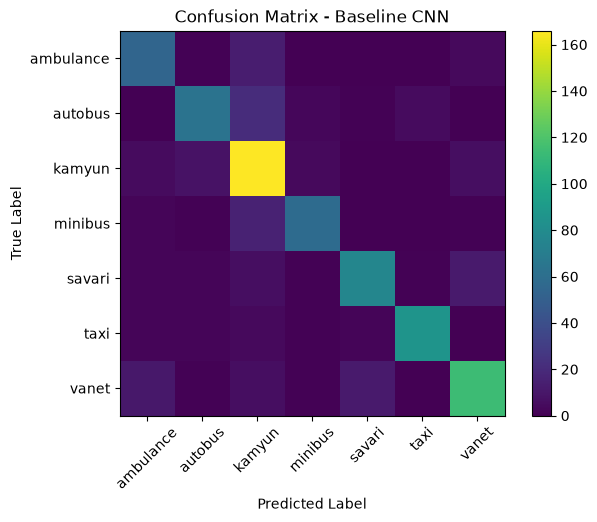

In [28]:
classes = [
    'ambulance',
    'autobus',
    'kamyun',
    'minibus',
    'savari',
    'taxi',
    'vanet'
]
plt.figure(figsize=(7, 5))
plt.imshow(cm)
plt.xticks(
    range(len(classes)),
    classes,
    rotation=45
)
plt.yticks(
    range(len(classes)),
    classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Baseline CNN")
plt.colorbar()
plt.show()

# classification_report

In [30]:
report = classification_report(all_labels_aug, all_predictions_aug, target_names=classes)
print(report)

              precision    recall  f1-score   support

   ambulance       0.71      0.75      0.73        72
     autobus       0.81      0.68      0.74        93
      kamyun       0.72      0.88      0.79       189
     minibus       0.85      0.74      0.79        78
      savari       0.84      0.76      0.80       100
        taxi       0.93      0.89      0.91        97
       vanet       0.83      0.79      0.81       145

    accuracy                           0.80       774
   macro avg       0.81      0.78      0.79       774
weighted avg       0.80      0.80      0.80       774

